# Home Safe — Ashford competitive analysis, Weeks 1 to 3 end to end

**Where can a new domiciliary care provider based at TN23 6LN (Ashford) credibly launch?**
LSA Data Engineering Internship — September 2026 cohort · worked example, 17 September 2026

This notebook runs the whole internship pipeline on one real dataset and ends with a stakeholder answer:

| Week | Step | In this notebook |
|---|---|---|
| 1 | Extract & understand the source | Sections 1–2 |
| 2 | Transform, enrich (geocode), test | Sections 3–5 |
| 3 | Quality gates, star schema, idempotent load, audit | Sections 6–7 |
| 4 | Analysis, maps, findings, recommendations | Sections 8–12 |

**Source:** CQC *Care Directory with Ratings* style bulk download, produced **16 September 2026** (57,127 locations, all of England).

> Contains Care Quality Commission information licensed under the Open Government Licence v3.0.

## 0. What is verified, what is assumed

**Verified by running it (this notebook, 17 September 2026):** every cell below executed top to bottom; the 23 tests in Section 5 pass with no network access; all 385 competitor postcodes were geocoded through [postcodes.io](https://postcodes.io) (free, no key) and cached to `postcode_geo_cache.csv`, so re-runs need no internet.

**Three assumptions that shape every number. Challenge them before quoting any figure:**

1. **"30 minutes' drive" is modelled as a 20-mile straight line.** No routing API was used. Real drive time follows the M20 and A2 much further than it follows a lane across Romney Marsh, so the east–west reach is understated and the rural south is overstated. Section 9 shows how to replace this with real drive times.
2. **A provider's registered address is not its service area.** CQC registers an office, not a territory. An agency based in Ashford may well serve New Romney. So "no provider based here" means *no local base*, not *nobody serving these people*. This is the single biggest limitation in the whole analysis.
3. **This bulk file has no CQC ratings and no registration dates**, unlike the Syndication API used in Weeks 1–3. Quality comparison and market-entry timing are therefore out of scope here. Section 12 says what the API would add.

## 1. Week 1 — Extract

The published directory has four title rows before the real header, so the header is row 5 (`skiprows=4`). Everything is read as text: postcodes and CQC IDs are identifiers, not numbers, and `CT1 3AA` must never become a float.

In [1]:
import os, sqlite3, sys
import numpy as np
import pandas as pd
pd.set_option("display.width", 160)

CANDIDATE_PATHS = [
    "16_september_2026_CQC_directory.csv",
    "../16_september_2026_CQC_directory.csv",
    "/mnt/user-data/uploads/16_september_2026_CQC_directory.csv",
]
CSV_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
assert CSV_PATH, ("Set CSV_PATH to the CQC directory download. Tried: " + ", ".join(CANDIDATE_PATHS))
print("Reading", CSV_PATH)

raw = pd.read_csv(CSV_PATH, skiprows=4, dtype=str)
print(f"{len(raw):,} locations x {raw.shape[1]} columns")
raw.head(3)

Reading 16_september_2026_CQC_directory.csv


57,127 locations x 15 columns


,Name,Also known as,Address,Postcode,Phone number,Service's website (if available),Service types,Date of latest check,Specialisms/services,Provider name,Local authority,Region,Location URL,CQC Location ID (for office use only),CQC Provider ID (for office use only)
0,Square Mile Dental Centre,NaN,"7-9 White Kennet Street,London",E1 7BS,2073770990,NaN,Dentist,09/Jan/2018 - 00:00,Services for everyone,Square Mile Dental Centre Limited,City of London,London,https://www.cqc.org.uk/location/1-10552899555,1-10552899555,1-10006912129
1,Helping Hands Mansfield,NaN,"Room 107, Level 1, East Wing,Mansfield Busines...",NG18 2AE,7436315363,NaN,Homecare agencies,19/May/2022 - 00:00,Caring for adults under 65 yrs|Dementia|Caring...,Midshires Care Limited,Nottinghamshire,East Midlands,https://www.cqc.org.uk/location/1-10553191017,1-10553191017,1-101671690
2,Oaksmere Dental Surgery,NaN,"99 Doncaster Road,Barnsley",S70 1TS,1226207444,NaN,Dentist,30/Aug/2016 - 00:00,Services for everyone,Oaksmere Dental Surgery Partnership,Barnsley,Yorkshire & Humberside,https://www.cqc.org.uk/location/1-10557401684,1-10557401684,1-10352609961


In [2]:
print("Columns:"); print(list(raw.columns))
print("\nMost common service types (one location can hold several, pipe-separated):")
print(raw["Service types"].str.split("|").explode().str.strip().value_counts().head(8))
print("\nNull counts where they matter:")
print(raw[["Postcode","Local authority","Provider name","Date of latest check",
           "Service's website (if available)"]].isna().sum())

Columns:
['Name', 'Also known as', 'Address', 'Postcode', 'Phone number', "Service's website (if available)", 'Service types', 'Date of latest check', 'Specialisms/services', 'Provider name', 'Local authority', 'Region', 'Location URL', 'CQC Location ID (for office use only)', 'CQC Provider ID (for office use only)']

Most common service types (one location can hold several, pipe-separated):
Service types
Doctors/GPs                        18607
Homecare agencies                  14478
Dentist                            12292
Residential homes                  10429
Supported living                    5021
Nursing homes                       4536
Diagnosis/screening                 1191
Community services - Healthcare      975
Name: count, dtype: int64

Null counts where they matter:
Postcode                                0
Local authority                        35
Provider name                           0
Date of latest check                14693
Service's website (if available)    2

**First real finding, before any analysis:** there is **no ratings column** in this file, despite the name the directory is published under, and no registration date. Weeks 1–3 used the CQC Syndication API, which carries `currentRatings` and `registrationDate`. Same regulator, different products. Always confirm which columns actually exist rather than assuming from the file's title.

## 2. Week 1 — Data dictionary

The Week 1 deliverable: what each field is, and whether it can be trusted for this question.

In [3]:
data_dictionary = pd.DataFrame([
 ("Name","Location (branch) name","Trade name, not the legal entity"),
 ("Address / Postcode","Registered office of the branch","NOT the area served — see assumption 2"),
 ("Service types","Pipe-separated CQC service types","'Homecare agencies' is our competitor filter"),
 ("Date of latest check","Date of the most recent CQC check","Blank for 42% of our catchment; blank does not prove 'never inspected'"),
 ("Specialisms/services","Pipe-separated specialisms","Self-declared at registration; may be stale"),
 ("Provider name","Legal entity owning the location","Used to measure chain concentration"),
 ("Local authority","County-level LA","'Kent' here, NOT the 12 districts the API returns"),
 ("CQC Location ID","Unique location key","Primary key of the fact table"),
 ("CQC Provider ID","Unique provider key","Foreign key to dim_provider"),
], columns=["field","meaning","caution"])
data_dictionary

,field,meaning,caution
0,Name,Location (branch) name,"Trade name, not the legal entity"
1,Address / Postcode,Registered office of the branch,NOT the area served — see assumption 2
2,Service types,Pipe-separated CQC service types,'Homecare agencies' is our competitor filter
3,Date of latest check,Date of the most recent CQC check,Blank for 42% of our catchment; blank does not...
4,Specialisms/services,Pipe-separated specialisms,Self-declared at registration; may be stale
5,Provider name,Legal entity owning the location,Used to measure chain concentration
6,Local authority,County-level LA,"'Kent' here, NOT the 12 districts the API returns"
7,CQC Location ID,Unique location key,Primary key of the fact table
8,CQC Provider ID,Unique provider key,Foreign key to dim_provider


**Second finding, and a trap for the cohort:** this file's `Local authority` is **county-level** (`Kent`, `Medway`), while the Syndication API returns **districts** (`Ashford`, `Swale`, …). Week 2's cleaning rule — match against the 12 Kent districts — would flag every Kent row in this file as unrecognised. Same regulator, same concept, different granularity: this is what a data dictionary is for.

## 3. Week 2 — Transform

The helper module below carries the cleaning rules from Week 2 and the load pattern from Week 3. It is written as plain functions with no network calls inside them, so Section 5 can test it without a key or an internet connection.

In [4]:
%%writefile homesafe_market.py
"""Home Safe — Ashford (TN23 6LN) domiciliary care market analysis.

Reusable, testable functions for the Week 1–4 walkthrough notebook:
  * cleaning and postcode handling (Week 2 rules)
  * geocoding with an on-disk cache and a postcodes.io fallback (network only
    when the cache misses, so the notebook runs offline)
  * haversine distance and drive-time-proxy catchment rings
  * data-quality gates + an idempotent SQLite star-schema load (Week 3 pattern)
  * market metrics: density, concentration (HHI) and an opportunity score

No network calls happen at import time. Every function below is unit-tested in
test_homesafe_market.py.
"""
from __future__ import annotations

import math
import re
import sqlite3
from dataclasses import dataclass, field
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# --- constants --------------------------------------------------------------
ANCHOR_POSTCODE = "TN23 6LN"          # Home Safe's assumed base, Ashford
EARTH_RADIUS_MILES = 3958.8

# Straight-line proxy for a 30-minute drive. See the notebook for why this is a
# proxy and not a fact: real drive time follows the M20 and A2 much further than
# it follows a country lane across Romney Marsh.
CATCHMENT_MILES = 20.0
RING_EDGES = [0, 5, 10, 15, 20]

UK_POSTCODE_RE = re.compile(r"^[A-Z]{1,2}\d[A-Z\d]?\s?\d[A-Z]{2}$")
HOMECARE_SERVICE = "Homecare agencies"
GP_SERVICE = "Doctors/GPs"
CARE_HOME_SERVICES = ("Residential homes", "Nursing homes")

OGL_ATTRIBUTION = ("Contains Care Quality Commission information licensed under "
                   "the Open Government Licence v3.0.")


# --- Week 2 cleaning helpers (same rules as the Week 2/3 material) -----------
def is_blank(value) -> bool:
    """NaN-aware blank test. NaN is truthy in Python, so never use `if value`
    on a pandas cell."""
    if value is None:
        return True
    if isinstance(value, float) and math.isnan(value):
        return True
    return str(value).strip() == "" or str(value).strip().lower() in {"nan", "nat", "none"}


def normalise_postcode(raw):
    """Upper-case, single space before the inward code. Returns None if blank."""
    if is_blank(raw):
        return None
    p = re.sub(r"\s+", "", str(raw)).upper()
    if len(p) < 5:
        return p
    return f"{p[:-3]} {p[-3:]}"


def postcode_key(raw):
    """Space-free key used for joining to the geocode cache."""
    pc = normalise_postcode(raw)
    return None if pc is None else pc.replace(" ", "")


def is_valid_uk_postcode(raw) -> bool:
    pc = normalise_postcode(raw)
    return bool(pc) and bool(UK_POSTCODE_RE.match(pc))


def outward_code(raw):
    """'TN23 6LN' -> 'TN23'. The postcode district, used as the analysis area."""
    pc = postcode_key(raw)
    if not pc or len(pc) < 5:
        return None
    return pc[:-3]


# --- extract / load of the CQC bulk directory -------------------------------
def read_cqc_directory(path: str) -> pd.DataFrame:
    """The published Care Directory CSV carries four title rows before the real
    header, so the header row is row 5 (skiprows=4). Everything is read as text:
    postcodes and CQC IDs are identifiers, not numbers."""
    df = pd.read_csv(path, skiprows=4, dtype=str)
    df.columns = [c.strip() for c in df.columns]
    return df


COLUMN_RENAMES = {
    "Name": "location_name",
    "Also known as": "also_known_as",
    "Address": "address",
    "Postcode": "postcode_raw",
    "Phone number": "phone",
    "Service's website (if available)": "website",
    "Service types": "service_types",
    "Date of latest check": "latest_check_raw",
    "Specialisms/services": "specialisms",
    "Provider name": "provider_name",
    "Local authority": "local_authority",
    "Region": "region",
    "Location URL": "location_url",
    "CQC Location ID (for office use only)": "location_id",
    "CQC Provider ID (for office use only)": "provider_id",
}


def tidy_directory(df: pd.DataFrame) -> pd.DataFrame:
    """Rename to snake_case, normalise postcodes, derive outward code and parse
    the inspection date. Nothing is dropped here — filtering comes later."""
    out = df.rename(columns=COLUMN_RENAMES).copy()
    out["postcode"] = out["postcode_raw"].apply(normalise_postcode)
    out["pc_key"] = out["postcode_raw"].apply(postcode_key)
    out["postcode_valid"] = out["postcode_raw"].apply(is_valid_uk_postcode)
    out["outcode"] = out["postcode_raw"].apply(outward_code)
    out["latest_check"] = pd.to_datetime(
        out["latest_check_raw"].str.split(" - ").str[0], format="%d/%b/%Y", errors="coerce")
    for col in ("service_types", "specialisms"):
        out[col] = out[col].fillna("")
    return out


def has_service(df: pd.DataFrame, *service_names) -> pd.Series:
    """Service types are pipe-separated in one cell, so an exact match needs the
    split — a plain `.str.contains('Homecare agencies')` would also hit a future
    value such as 'Homecare agencies (specialist)'."""
    sets = df["service_types"].fillna("").apply(lambda s: {p.strip() for p in s.split("|")})
    wanted = set(service_names)
    return sets.apply(lambda s: bool(s & wanted))


# --- geocoding ---------------------------------------------------------------
def load_geo_cache(path: str) -> pd.DataFrame:
    cache = pd.read_csv(path, dtype={"pc": str})
    cache["lat"] = pd.to_numeric(cache["lat"], errors="coerce")
    cache["lon"] = pd.to_numeric(cache["lon"], errors="coerce")
    return cache


def geocode_postcodes(pc_keys, cache: pd.DataFrame | None = None, allow_network: bool = False,
                      session=None) -> pd.DataFrame:
    """Return a DataFrame [pc, lat, lon, district] for the given space-free
    postcodes. Cache first; only the misses go to postcodes.io (free, no key,
    100 postcodes per POST) and only when allow_network=True."""
    wanted = sorted({k for k in pc_keys if k})
    have = cache[cache["pc"].isin(wanted)] if cache is not None else pd.DataFrame(
        columns=["pc", "lat", "lon", "district"])
    missing = [k for k in wanted if k not in set(have["pc"])]
    if not missing or not allow_network:
        if missing:
            print(f"{len(missing)} postcode(s) not in cache and network lookup is off; "
                  f"they will have no coordinates.")
        return have.reset_index(drop=True)

    import requests
    session = session or requests.Session()
    rows = []
    for i in range(0, len(missing), 100):
        batch = missing[i:i + 100]
        resp = session.post("https://api.postcodes.io/postcodes",
                            json={"postcodes": batch}, timeout=30)
        resp.raise_for_status()
        for item in resp.json()["result"]:
            res = item.get("result")
            rows.append({"pc": item["query"].replace(" ", "").upper(),
                         "lat": res["latitude"] if res else np.nan,
                         "lon": res["longitude"] if res else np.nan,
                         "district": (res or {}).get("admin_district")})
    return pd.concat([have, pd.DataFrame(rows)], ignore_index=True)


# --- geometry ----------------------------------------------------------------
def haversine_miles(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles. Works on scalars or numpy arrays."""
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    h = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_MILES * np.arcsin(np.sqrt(h))


def add_distance(df: pd.DataFrame, anchor_lat: float, anchor_lon: float) -> pd.DataFrame:
    out = df.copy()
    out["miles_from_anchor"] = haversine_miles(anchor_lat, anchor_lon, out["lat"], out["lon"])
    out["ring"] = pd.cut(out["miles_from_anchor"], RING_EDGES,
                         labels=[f"{a}-{b} mi" for a, b in zip(RING_EDGES, RING_EDGES[1:])],
                         include_lowest=True)
    return out


# --- market metrics ----------------------------------------------------------
def herfindahl_index(counts) -> float:
    """HHI on location share, 0–10,000. US DOJ/FTC guidance treats <1,500 as
    unconcentrated; it is a rule of thumb here, not a regulatory finding."""
    counts = np.asarray([c for c in counts if c > 0], dtype=float)
    if counts.sum() == 0:
        return 0.0
    shares = counts / counts.sum() * 100
    return float((shares ** 2).sum())


def opportunity_table(catchment: pd.DataFrame, all_locations: pd.DataFrame,
                      outcode_geo: pd.DataFrame, anchor_lat: float, anchor_lon: float,
                      max_miles: float = CATCHMENT_MILES) -> pd.DataFrame:
    """One row per postcode district inside the catchment:
      homecare  — registered homecare agencies based there (supply)
      gp / care_homes — CQC GP practices and care homes there, used ONLY as a
                        rough proxy for how many older people live there
                        (demand). It is a proxy, not a population figure.
      homecare_per_care_home — supply against that demand proxy; low = thin cover
    """
    geo = outcode_geo.copy()
    geo["miles_from_anchor"] = haversine_miles(anchor_lat, anchor_lon, geo["lat"], geo["lon"])
    geo = geo[geo["miles_from_anchor"] <= max_miles]

    here = all_locations[all_locations["outcode"].isin(geo["outcode"])]
    table = geo.set_index("outcode")[["lat", "lon", "district", "miles_from_anchor"]].copy()
    table["homecare"] = catchment.groupby("outcode").size()
    table["gp"] = here[has_service(here, GP_SERVICE)].groupby("outcode").size()
    table["care_homes"] = here[has_service(here, *CARE_HOME_SERVICES)].groupby("outcode").size()
    table[["homecare", "gp", "care_homes"]] = table[["homecare", "gp", "care_homes"]].fillna(0).astype(int)
    table["homecare_per_care_home"] = (table["homecare"] / table["care_homes"].replace(0, np.nan)).round(2)
    return table.sort_values("miles_from_anchor")


# --- Week 3 pattern: quality gates + idempotent star-schema load --------------
@dataclass
class QualityReport:
    results: list = field(default_factory=list)

    def add(self, name, passed, blocking=True, detail=""):
        self.results.append({"check": name, "passed": bool(passed),
                             "blocking": blocking, "detail": detail})

    @property
    def blocking_failures(self):
        return [r for r in self.results if r["blocking"] and not r["passed"]]

    @property
    def warnings(self):
        return [r for r in self.results if not r["blocking"] and not r["passed"]]

    @property
    def ok_to_load(self):
        return not self.blocking_failures

    def to_frame(self):
        return pd.DataFrame(self.results)


def run_quality_checks(locations: pd.DataFrame, min_geocoded_share=0.95) -> QualityReport:
    rep = QualityReport()
    required = ["location_id", "provider_id", "location_name", "postcode", "outcode",
                "lat", "lon", "service_types"]
    missing = [c for c in required if c not in locations.columns]
    rep.add("required_columns_present", not missing, detail=f"missing={missing}")
    if missing:
        return rep

    rep.add("not_empty", len(locations) > 0, detail=f"{len(locations)} rows")
    dups = locations["location_id"][locations["location_id"].duplicated()].tolist()
    rep.add("location_id_unique", not dups, detail=f"duplicates={dups[:5]}")
    rep.add("ids_present", not locations["location_id"].apply(is_blank).any()
            and not locations["provider_id"].apply(is_blank).any())
    rep.add("all_rows_are_homecare", bool(has_service(locations, HOMECARE_SERVICE).all()),
            detail="every row must carry the 'Homecare agencies' service type")

    share = float(locations["lat"].notna().mean())
    rep.add("geocoding_coverage", share >= min_geocoded_share,
            detail=f"{share:.1%} geocoded; minimum {min_geocoded_share:.0%}")
    rep.add("all_rows_geocoded", share == 1.0, blocking=False,
            detail=f"{int(locations['lat'].isna().sum())} row(s) without coordinates")

    inbox = locations["lat"].between(49.8, 55.9) & locations["lon"].between(-6.5, 2.1)
    rep.add("coordinates_inside_great_britain", bool(inbox[locations["lat"].notna()].all()),
            detail="lat/lon must fall inside a GB bounding box")

    bad_pc = int((~locations["postcode"].apply(is_valid_uk_postcode)).sum())
    rep.add("postcodes_well_formed", bad_pc == 0, blocking=False,
            detail=f"{bad_pc} malformed postcode(s), flagged not dropped")
    return rep


SCHEMA_SQL = """
PRAGMA foreign_keys = ON;
CREATE TABLE IF NOT EXISTS dim_provider (
    provider_id   TEXT PRIMARY KEY,
    provider_name TEXT NOT NULL,
    last_loaded_at TEXT NOT NULL
);
CREATE TABLE IF NOT EXISTS dim_area (
    outcode   TEXT PRIMARY KEY,
    district  TEXT,
    lat       REAL,
    lon       REAL
);
CREATE TABLE IF NOT EXISTS fact_homecare_location (
    snapshot_date      TEXT NOT NULL,
    location_id        TEXT NOT NULL,
    provider_id        TEXT NOT NULL REFERENCES dim_provider(provider_id),
    outcode            TEXT NOT NULL REFERENCES dim_area(outcode),
    location_name      TEXT,
    postcode           TEXT,
    lat                REAL,
    lon                REAL,
    miles_from_anchor  REAL,
    in_catchment       INTEGER NOT NULL,
    has_website        INTEGER NOT NULL,
    latest_check       TEXT,
    specialisms        TEXT,
    PRIMARY KEY (snapshot_date, location_id)
);
CREATE TABLE IF NOT EXISTS load_audit (
    run_id TEXT PRIMARY KEY, snapshot_date TEXT NOT NULL, finished_at TEXT,
    status TEXT NOT NULL, rows_in INTEGER, rows_loaded INTEGER, notes TEXT
);
"""


def connect(db_path: str) -> sqlite3.Connection:
    conn = sqlite3.connect(db_path)
    conn.execute("PRAGMA foreign_keys = ON;")   # off by default, per connection
    return conn


def load_snapshot(conn, locations: pd.DataFrame, snapshot_date: str):
    """Idempotent: dimensions upserted, this snapshot's facts deleted and
    re-inserted, all inside one transaction."""
    now = datetime.now(timezone.utc).isoformat(timespec="seconds")
    with conn:
        conn.executescript(SCHEMA_SQL)
        for pid, name in locations[["provider_id", "provider_name"]].drop_duplicates().values:
            conn.execute("INSERT INTO dim_provider VALUES (?,?,?) ON CONFLICT(provider_id) "
                         "DO UPDATE SET provider_name=excluded.provider_name, "
                         "last_loaded_at=excluded.last_loaded_at", (pid, name, now))
        areas = locations[["outcode", "district"]].drop_duplicates("outcode")
        for _, r in areas.iterrows():
            conn.execute("INSERT INTO dim_area (outcode, district) VALUES (?,?) "
                         "ON CONFLICT(outcode) DO UPDATE SET district=excluded.district",
                         (r["outcode"], r["district"]))
        conn.execute("DELETE FROM fact_homecare_location WHERE snapshot_date = ?", (snapshot_date,))
        rows = [(
            snapshot_date, r.location_id, r.provider_id, r.outcode, r.location_name, r.postcode,
            None if pd.isna(r.lat) else float(r.lat), None if pd.isna(r.lon) else float(r.lon),
            None if pd.isna(r.miles_from_anchor) else float(r.miles_from_anchor),
            int(bool(r.in_catchment)), int(not is_blank(r.website)),
            None if pd.isna(r.latest_check) else str(r.latest_check.date()), r.specialisms,
        ) for r in locations.itertuples()]
        conn.executemany("INSERT INTO fact_homecare_location VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?)", rows)
        loaded = conn.execute("SELECT COUNT(*) FROM fact_homecare_location WHERE snapshot_date=?",
                              (snapshot_date,)).fetchone()[0]
        if loaded != len(locations):
            raise RuntimeError(f"Reconciliation failed: {len(locations)} in, {loaded} loaded")
    return loaded


def run_pipeline(conn, locations: pd.DataFrame, snapshot_date: str):
    """Checks -> gate -> load -> audit. Returns (status, QualityReport)."""
    import uuid
    report = run_quality_checks(locations)
    run_id = uuid.uuid4().hex
    with conn:
        conn.executescript(SCHEMA_SQL)
    if not report.ok_to_load:
        notes = "; ".join(f"{r['check']}: {r['detail']}" for r in report.blocking_failures)
        with conn:
            conn.execute("INSERT INTO load_audit VALUES (?,?,?,?,?,?,?)",
                         (run_id, snapshot_date, datetime.now(timezone.utc).isoformat(timespec="seconds"),
                          "BLOCKED", len(locations), 0, notes))
        return "BLOCKED", report
    loaded = load_snapshot(conn, locations, snapshot_date)
    notes = "; ".join(f"{r['check']}: {r['detail']}" for r in report.warnings)
    with conn:
        conn.execute("INSERT INTO load_audit VALUES (?,?,?,?,?,?,?)",
                     (run_id, snapshot_date, datetime.now(timezone.utc).isoformat(timespec="seconds"),
                      "LOADED", len(locations), loaded, notes))
    return "LOADED", report


Overwriting homesafe_market.py


In [5]:
import importlib, homesafe_market as hm
importlib.reload(hm)

directory = hm.tidy_directory(raw)
homecare_england = directory[hm.has_service(directory, hm.HOMECARE_SERVICE)].copy()
print(f"Homecare agencies in England: {len(homecare_england):,}")

# Candidate competitors: the postcode areas that can reach Ashford — TN, CT, ME.
# Anything further out cannot be within 20 miles, so geocoding it would be wasted calls.
candidates = homecare_england[
    homecare_england["outcode"].str.match(r"^(TN|CT|ME)\d", na=False)].copy()
print(f"Candidates in the TN / CT / ME postcode areas: {len(candidates)}")
print(f"Malformed postcodes: {(~candidates['postcode_valid']).sum()}")
print(f"Duplicate location IDs: {candidates['location_id'].duplicated().sum()}")

Homecare agencies in England: 14,470
Candidates in the TN / CT / ME postcode areas: 472
Malformed postcodes: 0
Duplicate location IDs: 0


### Why `outward_code` strips three characters instead of pattern-matching

Written without its space, `CT2 8AJ` is `CT28AJ`. A regex such as `^[A-Z]{1,2}[0-9][A-Z0-9]?` reads that as outcode **CT28**, a district that does not exist, and quietly moves a Canterbury agency into a phantom area. A UK inward code is *always* exactly three characters, so removing the last three is the only safe rule. There is a test for this in Section 5.

## 4. Week 2 — Enrich: postcodes to coordinates

CQC gives a postcode, not a location. [postcodes.io](https://postcodes.io) is a free ONS-derived API — no key, no sign-up, 100 postcodes per POST. **Results are cached to disk**, so this notebook re-runs offline and nobody hammers a free service during a class.

This is the same enrichment lesson as Week 2's Companies House step: cache first, call the network only for misses, and record which rows failed.

In [6]:
GEO_CACHE = "postcode_geo_cache.csv"
ALLOW_NETWORK = False        # set True to look up anything missing from the cache

cache = hm.load_geo_cache(GEO_CACHE) if os.path.exists(GEO_CACHE) else None
geo = hm.geocode_postcodes(candidates["pc_key"].tolist() + ["TN236LN"],
                           cache=cache, allow_network=ALLOW_NETWORK)
if ALLOW_NETWORK:
    geo.to_csv(GEO_CACHE, index=False)      # only rewrite the cache when we actually fetched

anchor = geo[geo["pc"] == hm.ANCHOR_POSTCODE.replace(" ", "")].iloc[0]
ANCHOR_LAT, ANCHOR_LON = float(anchor["lat"]), float(anchor["lon"])
print(f"Anchor {hm.ANCHOR_POSTCODE} -> {ANCHOR_LAT:.5f}, {ANCHOR_LON:.5f} ({anchor['district']})")
print(f"Cache holds {len(geo)} postcodes; {int(geo['lat'].isna().sum())} could not be geocoded "
      f"(terminated postcodes still listed by CQC).")

Anchor TN23 6LN -> 51.13230, 0.86737 (Ashford)
Cache holds 385 postcodes; 3 could not be geocoded (terminated postcodes still listed by CQC).


In [7]:
located = candidates.merge(geo.rename(columns={"pc": "pc_key"}), on="pc_key", how="left")
located = hm.add_distance(located, ANCHOR_LAT, ANCHOR_LON)
located["in_catchment"] = located["miles_from_anchor"] <= hm.CATCHMENT_MILES

print(f"Geocoded: {located['lat'].notna().mean():.1%} of {len(located)} candidates")
for r in (5, 10, 15, 20, 25):
    print(f"  within {r:>2} miles: {(located['miles_from_anchor'] <= r).sum():>3} agencies")
catchment = located[located["in_catchment"]].copy()
print(f"\nCATCHMENT (<= {hm.CATCHMENT_MILES:.0f} miles): {len(catchment)} homecare agencies")

Geocoded: 99.4% of 472 candidates
  within  5 miles:  31 agencies
  within 10 miles:  41 agencies
  within 15 miles:  95 agencies
  within 20 miles: 212 agencies
  within 25 miles: 374 agencies

CATCHMENT (<= 20 miles): 212 homecare agencies


## 5. Week 2 — Automated tests

Pure functions, in-memory SQLite, no network and no keys. They cover the postcode traps, the distance maths against a known real distance, the exact-match service filter, the geocoding cache (including proof that a cached postcode is never re-requested), and every quality gate in Section 6.

In [8]:
%%writefile test_homesafe_market.py
"""pytest suite for homesafe_market.py — no network, no API keys."""
import numpy as np
import pandas as pd
import pytest

import homesafe_market as hm


# --- cleaning ---------------------------------------------------------------
def test_normalise_postcode_spacing_and_case():
    assert hm.normalise_postcode("tn236ln") == "TN23 6LN"
    assert hm.normalise_postcode("TN23  6LN") == "TN23 6LN"
    assert hm.normalise_postcode(np.nan) is None


def test_outward_code_handles_short_and_long_districts():
    assert hm.outward_code("TN23 6LN") == "TN23"
    assert hm.outward_code("CT1 3AA") == "CT1"          # 3-char outcode
    assert hm.outward_code("ME10 1NR") == "ME10"
    assert hm.outward_code(None) is None


def test_outward_code_does_not_mangle_short_postcodes():
    # 'CT2 8AJ' written without a space is 'CT28AJ' — a naive regex reads this
    # as outcode 'CT28' (which does not exist). Stripping the last three
    # characters is the only safe rule.
    assert hm.outward_code("CT2 8AJ") == "CT2"
    assert hm.outward_code("CT28AJ") == "CT2"


def test_postcode_validity():
    assert hm.is_valid_uk_postcode("TN23 6LN")
    assert not hm.is_valid_uk_postcode("NOT A POSTCODE")
    assert not hm.is_valid_uk_postcode(np.nan)


def test_is_blank_treats_nan_as_blank():
    assert hm.is_blank(np.nan) and hm.is_blank("   ") and not hm.is_blank("x")


def test_has_service_is_exact_not_substring():
    df = pd.DataFrame({"service_types": ["Homecare agencies|Supported living",
                                         "Homecare agencies (specialist)",
                                         "Doctors/GPs"]})
    assert hm.has_service(df, hm.HOMECARE_SERVICE).tolist() == [True, False, False]


# --- geometry ---------------------------------------------------------------
def test_haversine_against_known_distance():
    # Ashford (TN23 6LN) to Canterbury city centre (CT1 2AA): ~13-14 miles
    d = hm.haversine_miles(51.1323, 0.867371, 51.282506, 1.081612)
    assert 12.5 < d < 15.0


def test_haversine_zero_for_same_point():
    assert hm.haversine_miles(51.1323, 0.867371, 51.1323, 0.867371) == pytest.approx(0, abs=1e-9)


def test_rings_are_assigned_by_distance():
    df = pd.DataFrame({"lat": [51.1323, 51.282506], "lon": [0.867371, 1.081612]})
    out = hm.add_distance(df, 51.1323, 0.867371)
    assert str(out.loc[0, "ring"]) == "0-5 mi"
    assert str(out.loc[1, "ring"]) == "10-15 mi"


# --- market metrics ---------------------------------------------------------
def test_hhi_monopoly_and_fragmented():
    assert hm.herfindahl_index([10]) == pytest.approx(10000)
    assert hm.herfindahl_index([1] * 100) == pytest.approx(100)
    assert hm.herfindahl_index([]) == 0.0


# --- geocoding --------------------------------------------------------------
def test_geocode_uses_cache_and_never_calls_network_when_disabled():
    cache = pd.DataFrame({"pc": ["TN236LN"], "lat": [51.1323], "lon": [0.867371],
                          "district": ["Ashford"]})
    out = hm.geocode_postcodes(["TN236LN", "CT12AA"], cache=cache, allow_network=False)
    assert list(out["pc"]) == ["TN236LN"]      # the miss is reported, not fetched


def test_geocode_fetches_only_cache_misses():
    class FakeResponse:
        def __init__(self, payload): self._p = payload
        def raise_for_status(self): pass
        def json(self): return self._p

    class FakeSession:
        def __init__(self): self.calls = []
        def post(self, url, json, timeout):
            self.calls.append(json["postcodes"])
            return FakeResponse({"result": [{"query": pc, "result": {
                "latitude": 51.0, "longitude": 1.0, "admin_district": "Testshire"}}
                for pc in json["postcodes"]]})

    cache = pd.DataFrame({"pc": ["TN236LN"], "lat": [51.1323], "lon": [0.867371],
                          "district": ["Ashford"]})
    session = FakeSession()
    out = hm.geocode_postcodes(["TN236LN", "CT12AA"], cache=cache, allow_network=True,
                               session=session)
    assert session.calls == [["CT12AA"]]        # cached postcode not re-requested
    assert set(out["pc"]) == {"TN236LN", "CT12AA"}


# --- pipeline ---------------------------------------------------------------
def sample_locations():
    return pd.DataFrame([
        {"location_id": "1-1", "provider_id": "1-p1", "location_name": "Alpha Care",
         "postcode": "TN23 6LN", "outcode": "TN23", "district": "Ashford",
         "lat": 51.1323, "lon": 0.867371, "miles_from_anchor": 0.0, "in_catchment": True,
         "website": "https://a.example", "latest_check": pd.Timestamp("2025-03-01"),
         "specialisms": "Dementia", "service_types": "Homecare agencies",
         "provider_name": "Alpha Ltd"},
        {"location_id": "1-2", "provider_id": "1-p2", "location_name": "Beta Care",
         "postcode": "CT1 2AA", "outcode": "CT1", "district": "Canterbury",
         "lat": 51.282506, "lon": 1.081612, "miles_from_anchor": 13.6, "in_catchment": True,
         "website": np.nan, "latest_check": pd.NaT, "specialisms": "Dementia",
         "service_types": "Homecare agencies|Supported living", "provider_name": "Beta Ltd"},
    ])


@pytest.fixture
def conn():
    c = hm.connect(":memory:")
    yield c
    c.close()


def fact_rows(conn):
    return conn.execute("SELECT COUNT(*) FROM fact_homecare_location").fetchone()[0]


def test_clean_load_passes_every_gate(conn):
    status, report = hm.run_pipeline(conn, sample_locations(), "2026-09-16")
    assert status == "LOADED", report.to_frame()
    assert fact_rows(conn) == 2


def test_load_is_idempotent(conn):
    for _ in range(3):
        hm.run_pipeline(conn, sample_locations(), "2026-09-16")
    assert fact_rows(conn) == 2
    assert conn.execute("SELECT COUNT(*) FROM dim_provider").fetchone()[0] == 2


def test_new_snapshot_keeps_history(conn):
    hm.run_pipeline(conn, sample_locations(), "2026-09-16")
    hm.run_pipeline(conn, sample_locations(), "2026-10-16")
    assert fact_rows(conn) == 4


def test_missing_website_recorded_as_zero_not_null(conn):
    hm.run_pipeline(conn, sample_locations(), "2026-09-16")
    got = dict(conn.execute("SELECT location_id, has_website FROM fact_homecare_location"))
    assert got == {"1-1": 1, "1-2": 0}


def test_duplicate_location_id_blocks_and_writes_nothing(conn):
    bad = pd.concat([sample_locations(), sample_locations().head(1)], ignore_index=True)
    status, report = hm.run_pipeline(conn, bad, "2026-09-16")
    assert status == "BLOCKED"
    assert "location_id_unique" in [r["check"] for r in report.blocking_failures]
    assert fact_rows(conn) == 0


def test_non_homecare_row_blocks(conn):
    bad = sample_locations()
    bad.loc[1, "service_types"] = "Doctors/GPs"
    status, _ = hm.run_pipeline(conn, bad, "2026-09-16")
    assert status == "BLOCKED"


def test_low_geocoding_coverage_blocks(conn):
    bad = sample_locations()
    bad.loc[1, "lat"] = np.nan
    status, report = hm.run_pipeline(conn, bad, "2026-09-16")   # 50% geocoded
    assert status == "BLOCKED"
    assert "geocoding_coverage" in [r["check"] for r in report.blocking_failures]


def test_coordinates_outside_gb_block(conn):
    bad = sample_locations()
    bad.loc[1, "lat"] = 40.7      # New York
    bad.loc[1, "lon"] = -74.0
    status, _ = hm.run_pipeline(conn, bad, "2026-09-16")
    assert status == "BLOCKED"


def test_one_missing_geocode_in_many_is_a_warning(conn):
    many = pd.concat([sample_locations()] * 20, ignore_index=True)
    many["location_id"] = [f"1-{i}" for i in range(len(many))]
    many.loc[0, "lat"] = np.nan                     # 1/40 missing = 97.5% coverage
    status, report = hm.run_pipeline(conn, many, "2026-09-16")
    assert status == "LOADED"
    assert "all_rows_geocoded" in [r["check"] for r in report.warnings]


def test_audit_records_blocked_and_loaded_runs(conn):
    hm.run_pipeline(conn, sample_locations(), "2026-09-16")
    bad = sample_locations()
    bad.loc[1, "service_types"] = "Dentist"
    hm.run_pipeline(conn, bad, "2026-09-16")
    statuses = [r[0] for r in conn.execute("SELECT status FROM load_audit ORDER BY rowid")]
    assert statuses == ["LOADED", "BLOCKED"]


def test_opportunity_table_counts_supply_and_demand_proxies():
    catchment = sample_locations()
    all_locs = pd.DataFrame({
        "outcode": ["TN23", "TN23", "CT1", "TN29"],
        "service_types": ["Doctors/GPs", "Residential homes", "Nursing homes", "Residential homes"],
    })
    geo = pd.DataFrame({"outcode": ["TN23", "CT1", "TN29"],
                        "lat": [51.1395, 51.2774, 50.9942],
                        "lon": [0.8558, 1.0856, 0.9323],
                        "district": ["Ashford", "Canterbury", "Folkestone and Hythe"]})
    t = hm.opportunity_table(catchment, all_locs, geo, 51.1323, 0.867371)
    assert t.loc["TN23", "homecare"] == 1 and t.loc["TN23", "gp"] == 1
    assert t.loc["TN23", "care_homes"] == 1
    assert t.loc["TN29", "homecare"] == 0          # no supply, demand proxy present
    assert t.loc["TN29", "care_homes"] == 1
    assert pd.isna(t.loc["CT1", "homecare_per_care_home"]) is False


Overwriting test_homesafe_market.py


In [9]:
!python -m pytest test_homesafe_market.py -q -p no:cacheprovider --color=no

...........

...

.......

..                                                  [100%]
23 passed in 0.52s


## 6. Week 3 — Quality gates

Checks run **before** the database is touched. Blocking failures stop the load; warnings are recorded and let it through. Two gates are specific to this analysis:

- **`geocoding_coverage`** — below 95% geocoded, the map and every distance conclusion are unsafe, so the load stops.
- **`coordinates_inside_great_britain`** — a bounding-box check. A transposed latitude/longitude pair (a classic geospatial bug) puts a Kent agency in the North Sea or Kazakhstan, and every distance silently becomes nonsense.

In [10]:
report = hm.run_quality_checks(catchment)
print("OK to load:", report.ok_to_load)
report.to_frame()

OK to load: True


,check,passed,blocking,detail
0,required_columns_present,True,True,missing=[]
1,not_empty,True,True,212 rows
2,location_id_unique,True,True,duplicates=[]
3,ids_present,True,True,
4,all_rows_are_homecare,True,True,every row must carry the 'Homecare agencies' s...
5,geocoding_coverage,True,True,100.0% geocoded; minimum 95%
6,all_rows_geocoded,True,False,0 row(s) without coordinates
7,coordinates_inside_great_britain,True,True,lat/lon must fall inside a GB bounding box
8,postcodes_well_formed,True,False,"0 malformed postcode(s), flagged not dropped"


## 7. Week 3 — Star schema, idempotent load, audit

Grain: **one homecare location, as observed on one snapshot date** — the snapshot being the day CQC produced the file (16 September 2026), not the day we ran the code. Dimensions: provider and area (postcode district). Re-running replaces that snapshot rather than duplicating it.

In [11]:
DB_PATH = "home_safe_ashford.db"
SNAPSHOT_DATE = "2026-09-16"          # the date printed in the CQC file header
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)                # demo only

conn = hm.connect(DB_PATH)
for run in (1, 2):                    # twice, to show the load is idempotent
    status, rep = hm.run_pipeline(conn, catchment, SNAPSHOT_DATE)
    n = conn.execute("SELECT COUNT(*) FROM fact_homecare_location").fetchone()[0]
    print(f"Run {run}: {status}, fact rows = {n}")
print()
print(pd.read_sql("SELECT status, rows_in, rows_loaded, notes FROM load_audit", conn).to_string(index=False))

Run 1: LOADED, fact rows = 212


Run 2: LOADED, fact rows = 212

status  rows_in  rows_loaded notes
LOADED      212          212      
LOADED      212          212      


In [12]:
# The star schema now answers questions in SQL rather than pandas
pd.read_sql('''
    SELECT a.outcode, a.district, COUNT(*) AS agencies,
           ROUND(AVG(f.miles_from_anchor), 1) AS avg_miles,
           SUM(f.has_website) AS with_website
    FROM fact_homecare_location f
    JOIN dim_area a ON a.outcode = f.outcode
    WHERE f.snapshot_date = ?
    GROUP BY a.outcode, a.district
    ORDER BY agencies DESC
    LIMIT 10
''', conn, params=(SNAPSHOT_DATE,))

,outcode,district,agencies,avg_miles,with_website
0,ME14,Maidstone,22,17.7,9
1,ME10,Swale,20,15.9,9
2,ME15,Maidstone,20,17.2,13
3,CT1,Canterbury,17,13.8,11
4,TN24,Ashford,15,1.7,9
5,TN23,Ashford,12,0.8,8
6,ME8,Medway,8,19.6,7
7,CT16,Dover,7,18.8,6
8,CT6,Canterbury,7,19.2,4
9,ME13,Swale,7,12.5,4


## 8. Week 4 — How competitive is this market?

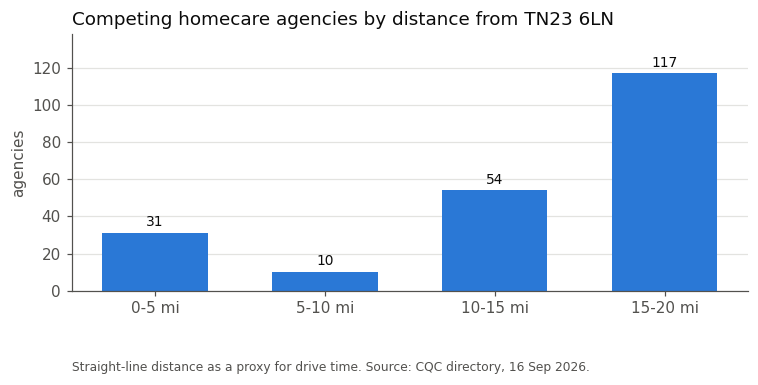

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRID, INK, MUTED = "#e3e3e0", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.edgecolor": MUTED,
                     "axes.labelcolor": MUTED, "text.color": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED})

def caption(ax, text):
    """Source/limitation note placed below the axis label, in offset points so it
    never collides with it whatever the figure size."""
    ax.annotate(text, xy=(0, 0), xycoords="axes fraction", xytext=(0, -46),
                textcoords="offset points", fontsize=8, color=MUTED, va="top")

def bar_labels(ax, bars, fmt="{:.0f}", pad=2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + pad,
                fmt.format(b.get_height()), ha="center", va="bottom", fontsize=9, color=INK)

ring_counts = catchment["ring"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(ring_counts.index.astype(str), ring_counts.values, color=BLUE, width=0.62)
bar_labels(ax, bars)
ax.set_title("Competing homecare agencies by distance from TN23 6LN", loc="left", fontsize=12, color=INK)
ax.set_ylabel("agencies"); ax.set_ylim(0, ring_counts.max()*1.18)
ax.yaxis.grid(True, color=GRID); ax.set_axisbelow(True)
caption(ax, "Straight-line distance as a proxy for drive time. Source: CQC directory, 16 Sep 2026.")
plt.tight_layout(); plt.show()

**The shape of the market: Ashford itself is not crowded — its neighbours are.** Only the innermost rings are genuinely local competition; most of the 20-mile count sits in the outer ring, where Maidstone, Medway and Canterbury pull the numbers up. An agency 18 miles away in Maidstone competes for staff far more than it competes for an Ashford client.

In [14]:
core = catchment[catchment["miles_from_anchor"] <= 10]
summary = pd.DataFrame({
    "within 10 miles": [len(core), core["provider_name"].nunique(),
                        hm.herfindahl_index(core.groupby("provider_name").size()),
                        core["website"].isna().mean()*100],
    "within 20 miles": [len(catchment), catchment["provider_name"].nunique(),
                        hm.herfindahl_index(catchment.groupby("provider_name").size()),
                        catchment["website"].isna().mean()*100],
}, index=["homecare agencies", "distinct providers", "HHI (location share)", "% with no website listed"])
summary.round(0)

,within 10 miles,within 20 miles
homecare agencies,41.0,212.0
distinct providers,39.0,189.0
HHI (location share),268.0,65.0
% with no website listed,32.0,40.0


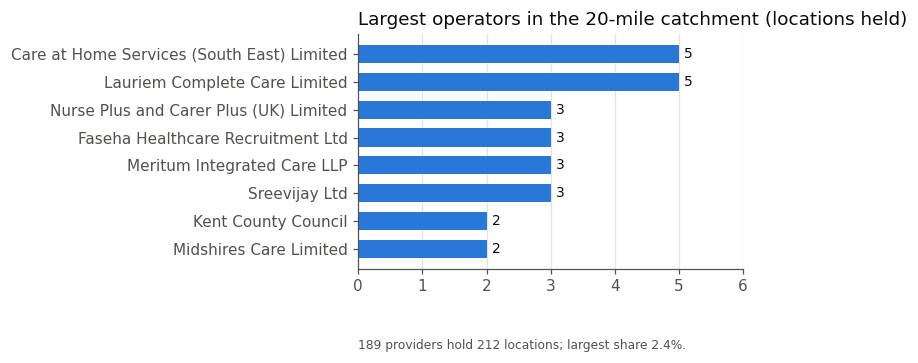

In [15]:
by_provider = catchment.groupby("provider_name").size().sort_values(ascending=False)
top = by_provider.head(8)
fig, ax = plt.subplots(figsize=(7, 3.4))
bars = ax.barh(top.index[::-1], top.values[::-1], color=BLUE, height=0.65)
for b in bars:
    ax.text(b.get_width()+0.08, b.get_y()+b.get_height()/2, f"{b.get_width():.0f}",
            va="center", fontsize=9, color=INK)
ax.set_title("Largest operators in the 20-mile catchment (locations held)", loc="left", fontsize=12, color=INK)
ax.set_xlim(0, top.max()*1.2); ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
caption(ax, f"{len(by_provider)} providers hold {len(catchment)} locations; "
             f"largest share {top.iloc[0]/len(catchment):.1%}.")
plt.tight_layout(); plt.show()

**Finding — the market is extremely fragmented, and that is the opening.** No operator holds more than about 2% of locations in the catchment; the top five together hold under a tenth. On the Herfindahl index (location share, 0–10,000) this scores in the double digits, far below the ~1,500 that US competition authorities treat as the bottom of "moderately concentrated". Rule of thumb, not a regulatory finding — but the direction is unambiguous.

For Home Safe that cuts both ways: **no dominant incumbent to displace**, and equally **no barrier to the next entrant either**. Nearly all competitors are single-branch operators, so the realistic threat is not a national chain — it is the next small local start-up, and there is nothing stopping one.

## 9. The map

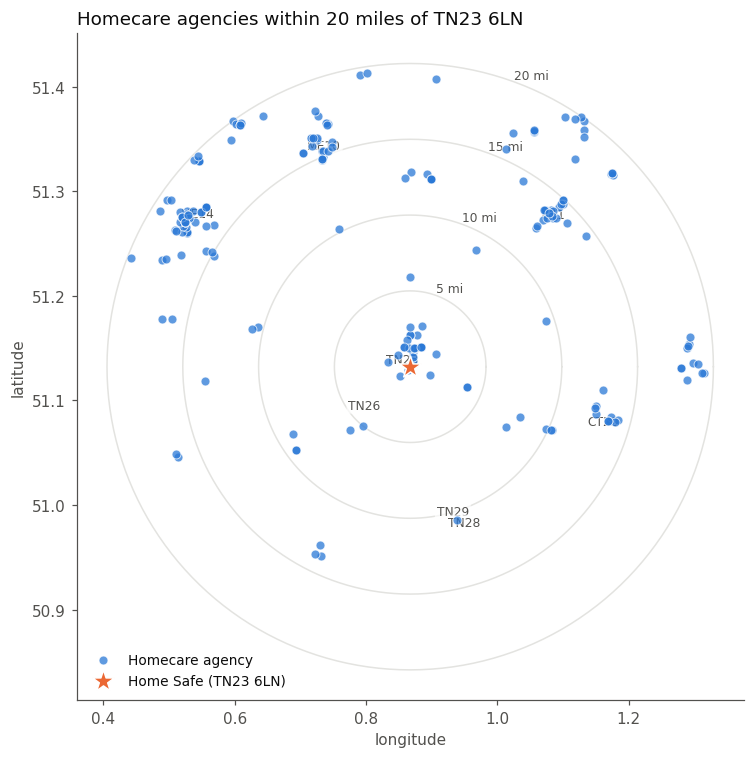

In [16]:
outcode_geo = pd.read_csv("outcode_geo_cache.csv")     # postcode-district centroids
oc_xy = outcode_geo.set_index("outcode")[["lat", "lon"]]

def deg_box(lat, lon, miles):
    """Approximate degree offsets for a mile radius at this latitude."""
    return miles/69.0, miles/(69.0*np.cos(np.radians(lat)))

plot = catchment.dropna(subset=["lat", "lon"])
fig, ax = plt.subplots(figsize=(7.6, 7))
for miles in (5, 10, 15, 20):
    dlat, dlon = deg_box(ANCHOR_LAT, ANCHOR_LON, miles)
    th = np.linspace(0, 2*np.pi, 361)
    ax.plot(ANCHOR_LON + dlon*np.cos(th), ANCHOR_LAT + dlat*np.sin(th),
            color=GRID, lw=1, zorder=1)
    ax.text(ANCHOR_LON + dlon*np.cos(np.radians(70)), ANCHOR_LAT + dlat*np.sin(np.radians(70)),
            f"{miles} mi", fontsize=8, color=MUTED, ha="left", va="bottom", zorder=1)
ax.scatter(plot["lon"], plot["lat"], s=34, color=BLUE, alpha=0.75,
           edgecolor="white", linewidth=0.6, zorder=3, label="Homecare agency")
ax.scatter([ANCHOR_LON], [ANCHOR_LAT], s=230, marker="*", color=ORANGE,
           edgecolor="white", linewidth=1, zorder=4, label="Home Safe (TN23 6LN)")
for oc in ["TN23", "CT1", "ME14", "ME10", "CT20", "TN29", "TN28", "TN26"]:
    if oc in oc_xy.index:
        ax.annotate(oc, (oc_xy.loc[oc, "lon"], oc_xy.loc[oc, "lat"]), fontsize=8,
                    color=MUTED, ha="center", va="center", zorder=2,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
ax.set_aspect(1/np.cos(np.radians(ANCHOR_LAT)))
ax.set_title("Homecare agencies within 20 miles of TN23 6LN", loc="left", fontsize=12, color=INK)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(frameon=False, loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

### An interactive version

`folium` writes a Leaflet map to a standalone HTML file. Open it in a browser (it needs internet for the map tiles). Rings are drawn at 10 and 20 miles, and each marker names the provider — that is the map to put in front of a stakeholder.

In [17]:
import folium
m = folium.Map(location=[ANCHOR_LAT, ANCHOR_LON], zoom_start=10, tiles="OpenStreetMap")
for miles, colour in ((10, ORANGE), (20, BLUE)):
    folium.Circle([ANCHOR_LAT, ANCHOR_LON], radius=miles*1609.34, color=colour,
                  weight=2, fill=False, opacity=0.6,
                  tooltip=f"{miles} miles straight line").add_to(m)
for _, r in plot.iterrows():
    folium.CircleMarker([r["lat"], r["lon"]], radius=4, color=BLUE, fill=True,
                        fill_opacity=0.8, weight=1,
                        tooltip=f"{r['location_name']} ({r['provider_name']}) — "
                                f"{r['miles_from_anchor']:.1f} mi").add_to(m)
folium.Marker([ANCHOR_LAT, ANCHOR_LON], tooltip="Home Safe — TN23 6LN",
              icon=folium.Icon(color="orange", icon="star")).add_to(m)
MAP_PATH = "home_safe_competitor_map.html"
m.save(MAP_PATH)
print("Saved", MAP_PATH, "— open it in a browser (needs internet for the tiles).")

Saved home_safe_competitor_map.html — open it in a browser (needs internet for the tiles).


## 10. Where are the gaps?

A gap needs both halves: **little supply** and **evident demand**. This file has no population data, so demand is proxied by **CQC care homes per postcode district** — where there are many care homes there are many older people. It is a proxy and a rough one: care homes are also substitutes for homecare, not only a sign of demand.

`homecare_per_care_home` is the ratio. Low means thin local homecare cover relative to an area that clearly has an older population.

In [18]:
opportunity = hm.opportunity_table(catchment, directory, outcode_geo, ANCHOR_LAT, ANCHOR_LON)
opportunity[["district", "miles_from_anchor", "homecare", "gp", "care_homes",
             "homecare_per_care_home"]].round(1).head(18)

,district,miles_from_anchor,homecare,gp,care_homes,homecare_per_care_home
outcode,,,,,,
TN23,Ashford,0.7,12,1,6,2.0
TN24,Ashford,1.5,15,7,11,1.4
TN25,Ashford,3.1,4,4,11,0.4
TN26,Ashford,4.0,2,3,11,0.2
TN27,Ashford,7.9,2,3,4,0.5
TN30,Ashford,8.8,3,1,3,1.0
CT21,Folkestone and Hythe,9.9,5,2,16,0.3
TN29,Folkestone and Hythe,9.9,0,1,9,0.0
CT4,Ashford,10.6,3,5,8,0.4


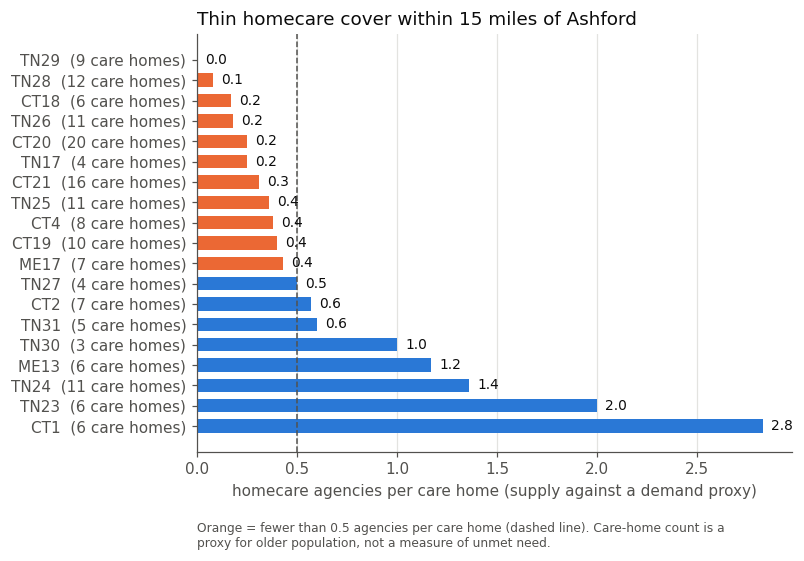

In [19]:
near = opportunity[opportunity["miles_from_anchor"] <= 15].copy()
near = near.sort_values("homecare_per_care_home", ascending=False, na_position="last")
thin = near["homecare_per_care_home"].fillna(0) < 0.5
colours = [ORANGE if t else BLUE for t in thin]

fig, ax = plt.subplots(figsize=(7.4, 5.2))
labels = [f"{oc}  ({int(r.care_homes)} care homes)" for oc, r in near.iterrows()]
vals = near["homecare_per_care_home"].fillna(0).values
bars = ax.barh(labels, vals, color=colours, height=0.66)
for b, v in zip(bars, vals):
    ax.text(b.get_width()+0.04, b.get_y()+b.get_height()/2, f"{v:.1f}", va="center",
            fontsize=9, color=INK)
ax.axvline(0.5, color=MUTED, lw=1, ls="--")
ax.set_title("Thin homecare cover within 15 miles of Ashford", loc="left", fontsize=12, color=INK)
ax.set_xlabel("homecare agencies per care home (supply against a demand proxy)")
caption(ax, "Orange = fewer than 0.5 agencies per care home (dashed line). Care-home count is a\n"
             "proxy for older population, not a measure of unmet need.")
ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [20]:
gaps = opportunity[(opportunity["miles_from_anchor"] <= 13) &
                   (opportunity["homecare"] <= 2) &
                   (opportunity["care_homes"] >= 6)].copy()
gaps["agencies_per_care_home"] = gaps["homecare_per_care_home"].fillna(0)
gaps[["district", "miles_from_anchor", "homecare", "care_homes", "agencies_per_care_home"]].round(1)

,district,miles_from_anchor,homecare,care_homes,agencies_per_care_home
outcode,,,,,
TN26,Ashford,4.0,2,11,0.2
TN29,Folkestone and Hythe,9.9,0,9,0.0
TN28,Folkestone and Hythe,10.9,1,12,0.1
CT18,Dover,12.3,1,6,0.2


**Finding — the gaps are rural and coastal, and they sit inside the drivable ring.** The districts with the least local homecare presence relative to their older population are Romney Marsh and New Romney (TN29, TN28), the Elham/Lyminge villages behind Folkestone (CT18), Hythe (CT21) and the villages between Ashford and Tenterden (TN26, TN25). All are within roughly 12 miles of TN23 6LN.

**Read this as a hypothesis, not a conclusion.** It says no agency is *based* there. Ashford- and Folkestone-based agencies may already cover these rounds. What the data does say is that anyone serving those clients is travelling to them, which means travel time between visits is the local cost problem — and that is exactly what a nearer base, or a round built around a village cluster, can beat.

## 11. Where competitors are weak

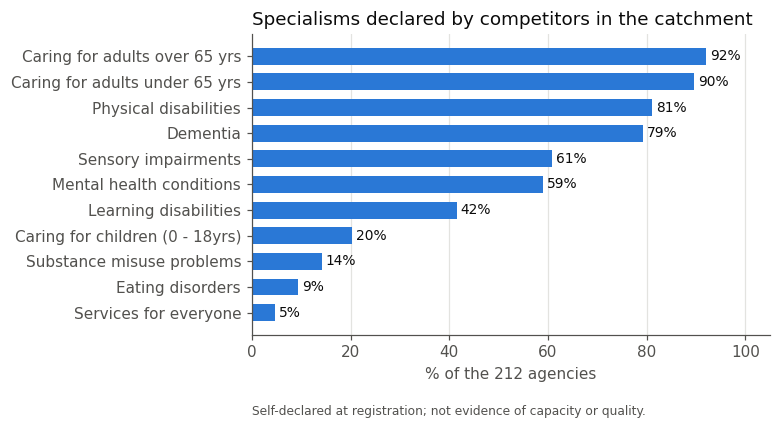

In [21]:
spec = (catchment["specialisms"].str.split("|").explode().str.strip()
        .replace("", np.nan).dropna().value_counts() / len(catchment) * 100)
fig, ax = plt.subplots(figsize=(7.2, 4))
bars = ax.barh(spec.index[::-1], spec.values[::-1], color=BLUE, height=0.66)
for b in bars:
    ax.text(b.get_width()+0.8, b.get_y()+b.get_height()/2, f"{b.get_width():.0f}%",
            va="center", fontsize=9, color=INK)
ax.set_title("Specialisms declared by competitors in the catchment", loc="left", fontsize=12, color=INK)
ax.set_xlabel("% of the 212 agencies"); ax.set_xlim(0, 105)
ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
caption(ax, "Self-declared at registration; not evidence of capacity or quality.")
plt.tight_layout(); plt.show()

In [22]:
print(f"No website listed:        {catchment['website'].isna().sum():>3} of {len(catchment)} "
      f"({catchment['website'].isna().mean():.0%})")
print(f"No 'date of latest check': {catchment['latest_check'].isna().sum():>3} of {len(catchment)} "
      f"({catchment['latest_check'].isna().mean():.0%})")
checked = catchment["latest_check"].dropna()
print(f"Checked since Jan 2024:    {(checked >= '2024-01-01').sum():>3} of {len(checked)} with a date")
print(f"Oldest check {checked.min():%b %Y} · newest {checked.max():%b %Y}")

No website listed:         84 of 212 (40%)
No 'date of latest check':  89 of 212 (42%)
Checked since Jan 2024:     20 of 123 with a date
Oldest check Jul 2017 · newest Sep 2026


**Findings on competitor weakness:**

- **Everyone claims the same ground.** Older adults (92%), physical disability (81%) and dementia (79%) are near-universal declarations. Differentiating on "we do dementia care" says nothing a commissioner or family has not read 200 times.
- **The thinner specialisms are the defensible ones.** Learning disability is declared by 42%, children's services by 20%, eating disorders by 9% and substance misuse by 14%. Fewer competitors, higher-rate packages, and a harder workforce to recruit — which is what keeps a niche defensible.
- **Two in five list no website at all.** In a market where families search before they phone, that is a straightforward marketing advantage for a new entrant with a decent site and local search presence.
- **Two in five have no inspection date recorded.** Treat this carefully: a blank may mean newly registered and not yet inspected, or simply not published in this extract. It is a question to take to the CQC API, not a conclusion (roughly 60% confidence it mostly reflects newer registrations).

## 12. Recommendations for the stakeholder

**The headline:** the Ashford catchment is a fragmented, low-concentration market with no dominant operator, thin local provision in the rural south and on the coast, and near-universal sameness in what competitors say they offer. Entry is viable. The binding constraint is not competition for clients — it is **staff, travel time and commissioning access**.

**1. Base the operation in Ashford, build the rounds south and south-east.**
TN23/TN24 has 27 agencies, so Ashford town itself is contested. The rural belt within 12 miles — Romney Marsh, New Romney, Hythe, the villages towards Tenterden — has very few agencies based there. Win where competitors' travel time is worst, not where their offices are.

**2. Verify the gap before committing — one week of work, not a quarter.**
The registered-address limitation means "no local base" is a hypothesis. Test it by: asking Kent County Council for its domiciliary care framework provider list and any areas flagged hard to cover; calling five care homes and two GP practices in TN29/TN28 to ask who actually visits; and checking whether local agencies say "we cover the Marsh" on their websites. If they all do, the gap is competitive, not empty.

**3. Differentiate on a specialism, not on "quality care".**
Learning disability (42% of competitors), complex/children's packages (20%) and substance misuse (14%) are declared by a minority. Pick one that matches the clinical skills available and price accordingly. Where everyone declares the same three specialisms, the only remaining lever is price, and price competition against 189 providers is not a strategy.

**4. Treat the website as infrastructure, not marketing.**
Two in five competitors list no website. A clear site, a Google Business listing and honest pricing put Home Safe in front of self-funding families at close to zero marginal cost. Self-funders also pay better than council-framework rates.

**5. Plan for the staffing market, because that is what decides the outcome.**
189 providers inside 20 miles are recruiting from the same pool of care workers. Before launch, model carer pay, mileage and travel time between visits for a rural round. A tight village cluster wins on travel economics; a scattered rural round loses money however good the care is.

**6. Watch the entry rate quarterly.**
Almost every competitor is a single-branch operator, so barriers to entry are low both ways. Re-run this notebook against each monthly CQC directory and track new registrations in the target districts. Section 7's snapshot design already supports this: each month loads as a new `snapshot_date` and the history stays intact.

**What would change this answer:** hard evidence that Ashford agencies already cover the rural south (kills recommendation 1); CQC ratings showing weak incumbents nearby (strengthens a head-on Ashford entry); or Kent County Council closing its framework to new providers (pushes the model towards self-funders).

## 13. Limitations, and what to do next

| Limitation | Effect | Fix |
|---|---|---|
| Registered address ≠ service area | Gaps may be covered by agencies based elsewhere | Council framework list; call providers; read their coverage pages |
| 20-mile straight line stands in for a 30-minute drive | M20 corridor understated, rural south overstated | Real isochrones: openrouteservice (free key) or a local OSRM |
| No ratings in this file | No quality comparison of competitors | CQC Syndication API `currentRatings` (Weeks 1–3) |
| No registration dates | Market entry and churn rates unknown | Same API: `registrationDate` |
| Care homes proxy for older population | Crude demand measure | ONS mid-year population by LSOA, aged 65+; Kent JSNA |
| Specialisms are self-declared | Overstates real capability | Inspection reports; spot calls |
| One monthly snapshot | No trend | Re-run monthly; Section 7 keeps history by snapshot date |

**Exercise for the cohort:** swap the straight-line ring for a real 30-minute isochrone and re-run Section 10. Which districts leave the catchment, and which join it? If the recommendation changes, the geography was doing more work than the analysis.

In [23]:
conn.close()
print("Outputs written:")
for f in ["home_safe_ashford.db", "home_safe_competitor_map.html", "postcode_geo_cache.csv"]:
    print(f"  {f}: {'yes' if os.path.exists(f) else 'MISSING'}")

Outputs written:
  home_safe_ashford.db: yes
  home_safe_competitor_map.html: yes
  postcode_geo_cache.csv: yes
